---
# Pre-TARE Adoption KPIs: Spark Gap, Thermal COP, Break-Even COP
---

**Author:** Jordan M. Joseph, PhD â€” Carnegie Mellon University

Computes adoption economics metrics that can be calculated directly from EUSS
data and EIA fuel prices, without requiring a TARE model run.

**Workflow:** Load EUSS data â†’ spark gap â†’ thermal COP & AFUE â†’ break-even COP â†’ maps

**Batch Mode:** Set `input_measure_package` before calling via `%run -i` to skip prompts.

See `README_adoption_kpis.md` for methodology notes and design decisions.

In [1]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import VALID_MENU_MPS, PA_COP_RANGES, JENKINS_BREAKEVEN_REF_90
from cmu_tare_model.adoption_kpis import (
    load_euss_baseline, load_euss_upgrade, mp_to_upgrade,
    calculate_spark_gap, compute_thermal_cop, compute_breakeven_cop,
)
from cmu_tare_model.adoption_kpis.thermal_cop import COP_BENCHMARK_RANGES
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe, create_choropleth_map, plot_combined_choropleth,
)
from cmu_tare_model.adoption_kpis.data_loading import FUEL_PRICES_PATH, SHAPEFILE_PATH

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
SAVE_FIGURES = False  # Set to True to save figure files to disk
print("[OK] Imports loaded")
print(f"Project root: {PROJECT_ROOT}")


Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
[OK] Imports loaded
Project root: c:\users\jorda\desktop\projects\cmu-tare-model


In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"\nSelected measure packages: {selected_mps}")

Available measure packages: [3, 4]

Selected measure packages: [3, 4]


In [3]:
print("=" * 80)
print("STEP 1: LOAD EUSS DATA")
print("=" * 80)

df_baseline = load_euss_baseline()
print(f"  Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n[OK] STEP 1 COMPLETE")

STEP 1: LOAD EUSS DATA
Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:180: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
  Baseline: 331,531 occupied SF homes

Loading MP3 (upgrade03)...
Loading upgrade03 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:214: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP3: 331,526 applicable homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:214: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP4: 331,526 applicable homes

[OK] STEP 1 COMPLETE


---
## Step 2: Fuel Price Ratios (Spark Gap)
---

In [4]:
print("=" * 60)
print("STEP 2: SPARK GAP (2024 EIA nominal prices)")
print("=" * 60)

df_spark_gap = calculate_spark_gap(FUEL_PRICES_PATH, year=2024)
print(f"[OK] {len(df_spark_gap)} states loaded")
print(f"  Mean: {df_spark_gap['spark_gap'].mean():.2f}, "
      f"Range: {df_spark_gap['spark_gap'].min():.2f}"
      f"â€“{df_spark_gap['spark_gap'].max():.2f}")
fl = float(df_spark_gap[df_spark_gap['state'] == 'FL']['spark_gap'].values[0])
ak = float(df_spark_gap[df_spark_gap['state'] == 'AK']['spark_gap'].values[0])
print(f"  FL: {fl:.2f}, AK: {ak:.2f}")
print("[OK] STEP 2 COMPLETE")


STEP 2: SPARK GAP (2024 EIA nominal prices)
[OK] 51 states loaded
  Mean: 3.54, Range: 1.69â€“6.42
  FL: 1.69, AK: 6.42
[OK] STEP 2 COMPLETE


---
## Step 3: Thermal COP and Baseline AFUE
---

In [5]:
print("=" * 60)
print("STEP 3: THERMAL COP (Natural Gas homes)")
print("=" * 60)

cop_results = {}
for mp in selected_mps:
    print(f"\nMP{mp}:")
    cop_results[mp] = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        fuel_filter='Natural Gas', verbose=True,
    )
    print(f"\nMean COP for MP{mp}: {cop_results[mp]['thermal_cop'].mean():.3f}")

print(f"\n[OK] STEP 3 COMPLETE")


STEP 3: THERMAL COP (Natural Gas homes)

MP3:
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by state) ---
Groups: 49
Mean:   2.21
Median: 2.20
Range:  1.53 - 3.05
[OK] All groups within COP range [1.5, 5.0]

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.75 - 0.82

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   3.8%
Range:  1.7% - 5.8%

Mean COP for MP3: 2.213

MP4:
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by state) ---
Groups: 49
Mean:   3.89
Median: 3.98
Range:  2.15 - 5.72
[WARN] 8 group(s) with COP outside [1.5, 5.0]:
    AL: 5.06
    CA: 5.72
    FL: 5.70
    GA: 5.06
    LA: 5.35
    MS: 5.02
    SC: 5.06
    TX: 5.30

---

---
### Climate Zone Benchmark Validation
---

Aggregates thermal COP by IECC climate zone group and validates against
literature-derived benchmark ranges (`COP_BENCHMARK_RANGES`). Also
produces a state Ã— climate zone cross-tab with a PA spot check.

In [6]:
print("=" * 60)
print("CLIMATE ZONE BENCHMARK VALIDATION")
print("=" * 60)

for mp in selected_mps:
    mp_key = f'mp{mp}'
    print(f"\n--- MP{mp} Climate Zone Group Aggregation ---")

    df_cop_cz = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['cz_group'],
        fuel_filter='Natural Gas',
        verbose=True,
    )

    df_cop_state_cz = compute_thermal_cop(
        df_baseline, upgrade_data[mp],
        group_cols=['state', 'cz_group'],
        fuel_filter='Natural Gas',
        verbose=False,
    )

    print(f"\n--- Benchmark Validation (MP{mp}) ---")
    print(f"{'CZ Group':<10} {'Label':<18} {'COP':>6} {'Expected':>14} {'Pass':>6}")
    print("-" * 58)
    n_checked = 0
    n_passed = 0
    for cz_grp, bench in COP_BENCHMARK_RANGES.items():
        row = df_cop_cz[df_cop_cz['cz_group'] == cz_grp]
        if len(row) == 0:
            print(f"{cz_grp:<10} {bench['label']:<18} {'N/A':>6} {'':<14} {'SKIP':>6}")
            continue
        cop_val = row['thermal_cop'].values[0]
        if mp_key in bench:
            lo, hi = bench[mp_key]
            in_range = lo <= cop_val <= hi
            n_checked += 1
            n_passed += int(in_range)
            range_str = f"[{lo:.1f}, {hi:.1f}]"
            print(f"{cz_grp:<10} {bench['label']:<18} {cop_val:>6.2f} {range_str:>14} "
                  f"{'[OK]' if in_range else '[FAIL]':>6}")
        else:
            print(f"{cz_grp:<10} {bench['label']:<18} {cop_val:>6.2f} {'no bench':>14} {'â€”':>6}")
    print(f"\nOverall: {n_passed}/{n_checked} climate zone groups within expected range")

    pa_rows = df_cop_state_cz[df_cop_state_cz['state'] == 'PA']
    if len(pa_rows) > 0:
        print(f"\n--- PA Spot Check (MP{mp}) ---")
        for _, pa_row in pa_rows.iterrows():
            cop_val = pa_row['thermal_cop']
            cz = pa_row['cz_group']
            if mp_key in PA_COP_RANGES:
                lo, hi = PA_COP_RANGES[mp_key]
                ok = lo <= cop_val <= hi
                print(f"  PA (CZ {cz}): COP = {cop_val:.2f}, "
                      f"expected [{lo:.1f}, {hi:.1f}] -> {'[OK] PASS' if ok else '[FAIL] FAIL'}")
            else:
                print(f"  PA (CZ {cz}): COP = {cop_val:.2f} (no PA benchmark for {mp_key})")
    else:
        print("\n[WARN] PA not found in state x CZ cross-tab")

print(f"\n[OK] VALIDATION COMPLETE")


CLIMATE ZONE BENCHMARK VALIDATION

--- MP3 Climate Zone Group Aggregation ---
Matched homes (baseline ∩ upgrade): 331,526
Filtered to 'Natural Gas': 180,939 / 331,526 (54.6%)
Excluded 683 homes with zero baseline heating (180,256 remaining)

--- Thermal COP Summary (Natural Gas, by cz_group) ---
Groups: 3
Mean:   2.15
Median: 2.05
Range:  1.67 - 2.74
[OK] All groups within COP range [1.5, 5.0]

--- Baseline AFUE Summary (Natural Gas) ---
Mean:   0.80
Median: 0.80
Range:  0.80 - 0.81

--- Fan/Pump Energy as % of Total HP Electricity ---
Mean:   3.4%
Range:  2.2% - 4.8%

--- Benchmark Validation (MP3) ---
CZ Group   Label                 COP       Expected   Pass
----------------------------------------------------------
1-3        Warm (CZ 1-3)        2.74     [2.4, 3.2]   [OK]
4-5        Mixed (CZ 4-5)       2.05     [2.0, 2.8]   [OK]
6-7        Cold (CZ 6-7)        1.67     [1.6, 2.4]   [OK]

Overall: 3/3 climate zone groups within expected range

--- PA Spot Check (MP3) ---
  PA (CZ 

---
## Step 4: Break-Even COP and Merged Metrics
---

In [7]:
print("=" * 60)
print("STEP 4: BREAK-EVEN COP")
print("=" * 60)

breakeven_results = {}
for mp in selected_mps:
    breakeven_results[mp] = compute_breakeven_cop(
        df_spark_gap, cop_results[mp]
    )
    be90 = breakeven_results[mp]['breakeven_cop_90']
    print(f"  MP{mp} BE @90% AFUE — Mean: {be90.mean():.2f}, "
          f"Range: {be90.min():.2f}–{be90.max():.2f}")

# Jenkins validation — break-even depends on spark gap + AFUE; validate against first MP
df_be_validate = breakeven_results[selected_mps[0]]
n_pass, n_total = 0, len(JENKINS_BREAKEVEN_REF_90)
for st, ref in JENKINS_BREAKEVEN_REF_90.items():
    row = df_be_validate[df_be_validate['state'] == st]
    if len(row) > 0 and abs(float(row['breakeven_cop_90'].values[0]) - ref) <= 0.50:
        n_pass += 1
print(f"Jenkins validation (+-0.50, MP{selected_mps[0]}): {n_pass}/{n_total} states")
print("[OK] STEP 4 COMPLETE")


STEP 4: BREAK-EVEN COP
  MP3 BE @90% AFUE — Mean: 3.15, Range: 1.52–4.90
  MP4 BE @90% AFUE — Mean: 3.15, Range: 1.52–4.90
Jenkins validation (+-0.50, MP3): 5/6 states
[OK] STEP 4 COMPLETE


---
## Step 5: Geospatial Visualization
---

In [8]:
gdf_states_raw = None

try:
    print(f"Loading shapefile from: {SHAPEFILE_PATH}")
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    print(f"[OK] Shapefile loaded: {len(gdf_states_raw)} features")
except FileNotFoundError:
    print(f"[WARN] Shapefile not found at {SHAPEFILE_PATH} — skipping maps")
except Exception as e:
    print(f"[WARN] Could not load shapefile: {e}")


Loading shapefile from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\electricity_ng_price_ratio\nhgis0011_shapefile_tl2015_us_state_2015\US_state_2015.shp
[OK] Shapefile loaded: 52 features


Generating choropleth maps...


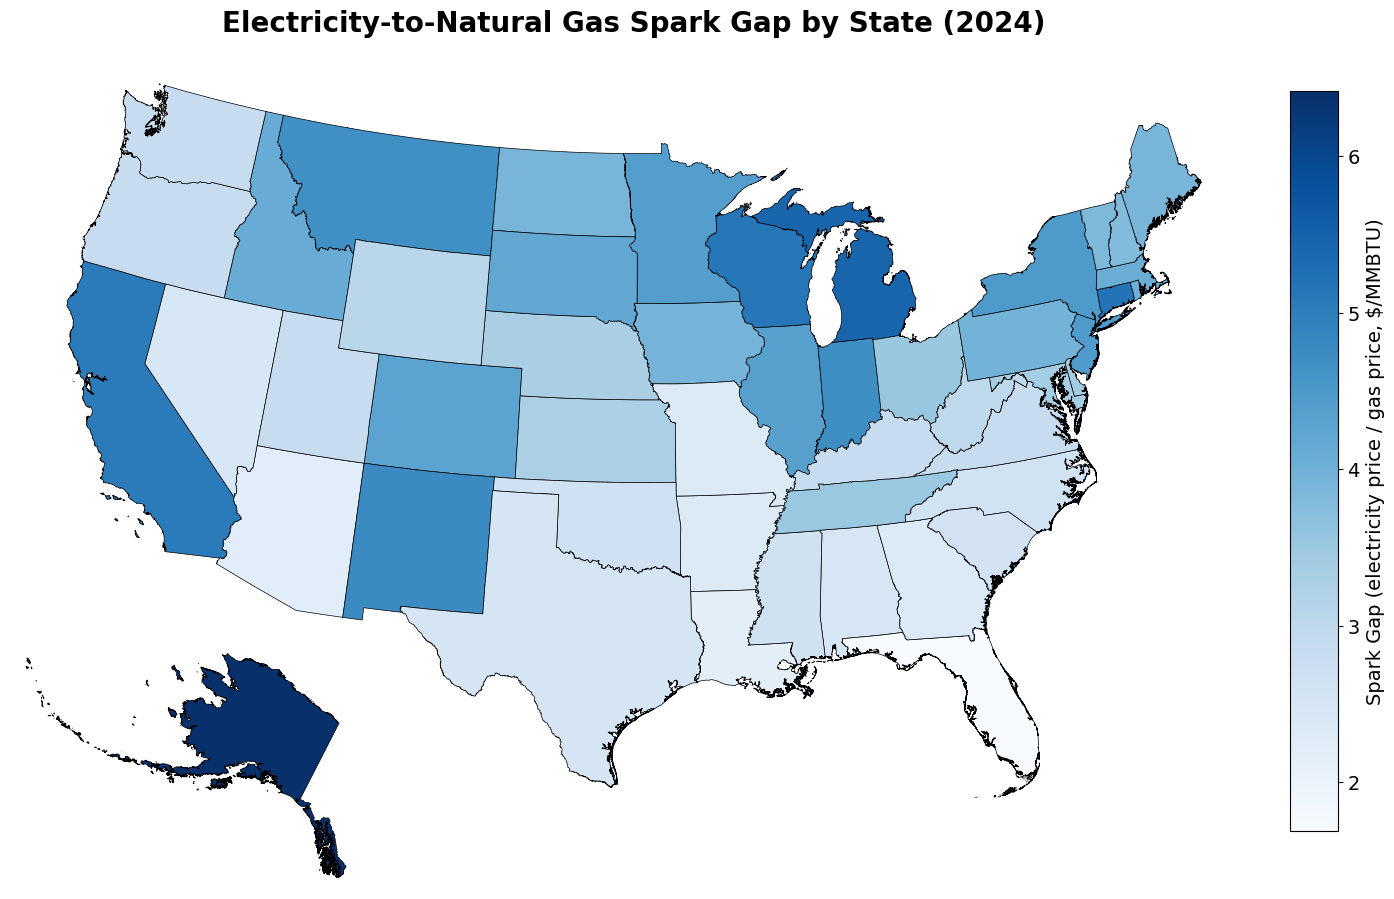

COP shared scale: 1.53 – 5.72


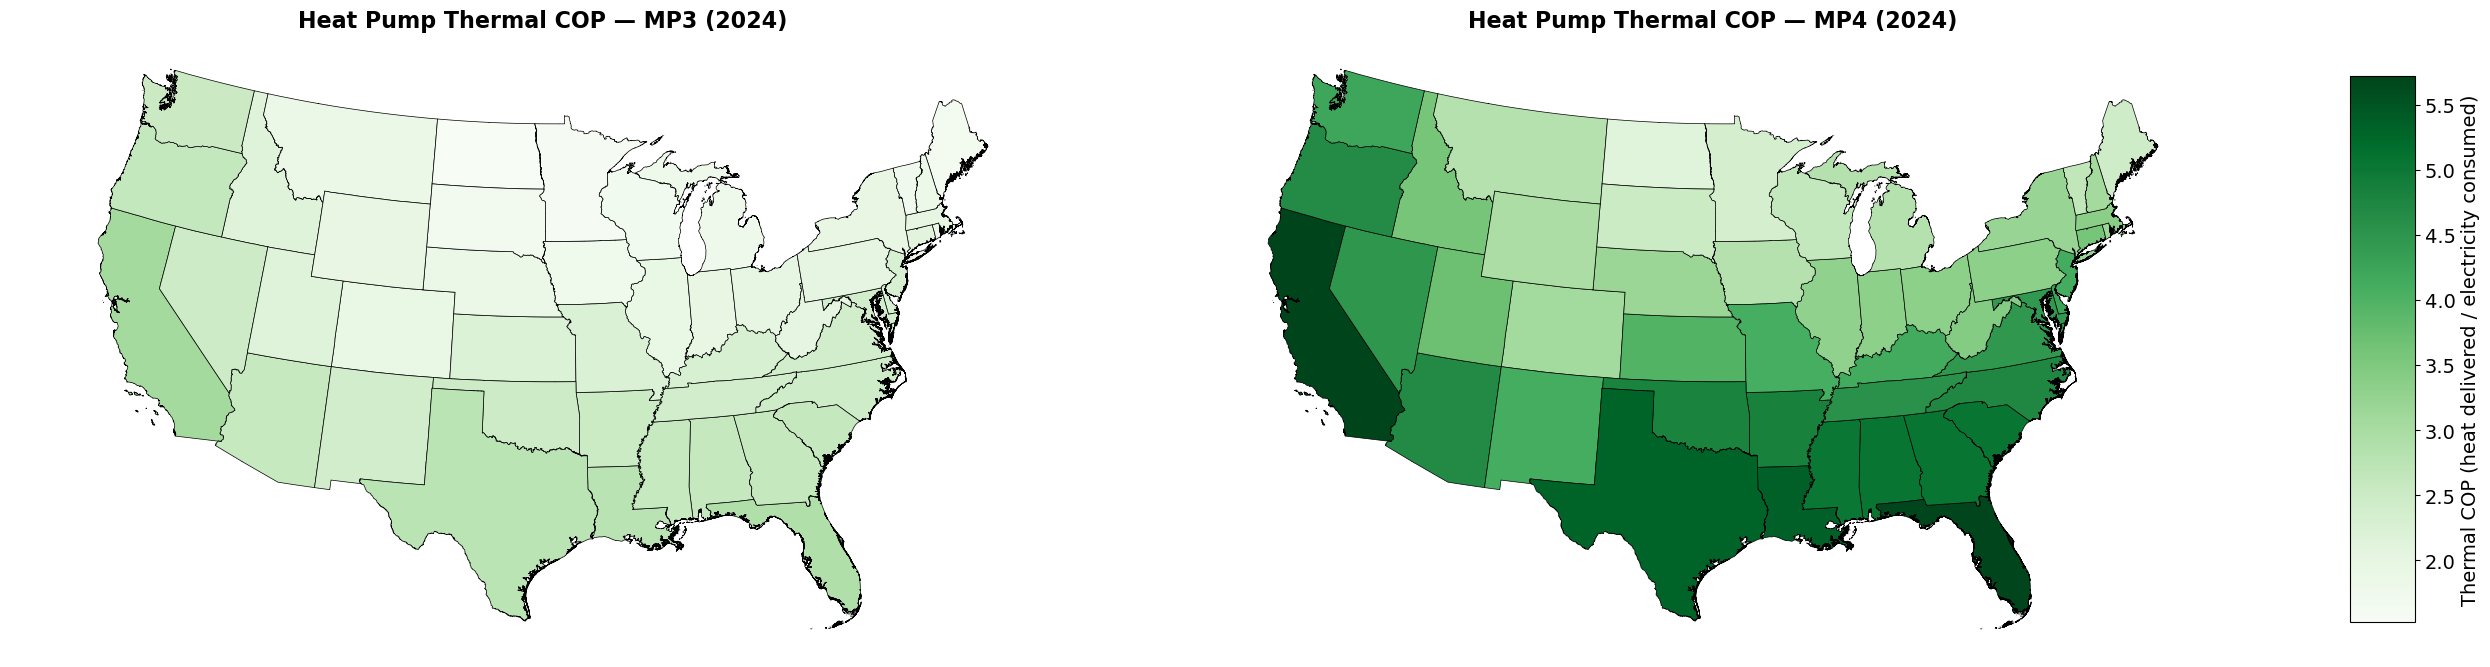

Break-even COP shared scale: 1.52 – 4.90


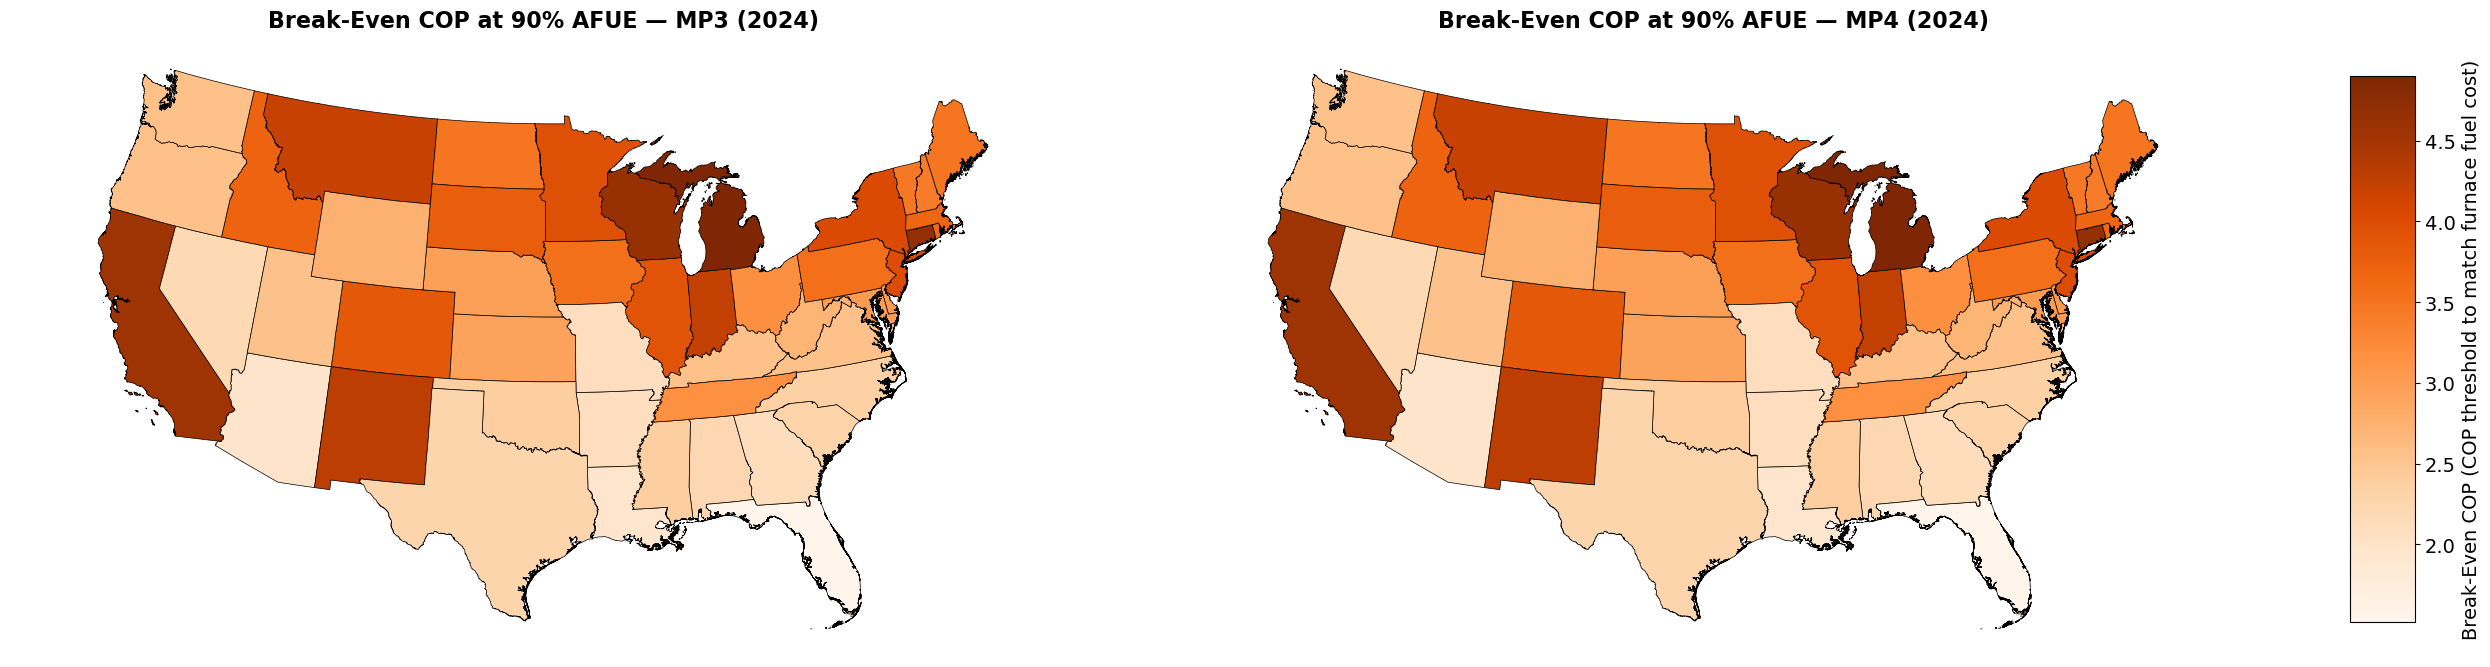

[OK] Maps generated


In [9]:
if gdf_states_raw is not None:
    print("Generating choropleth maps...")

    # ---- Spark gap: single map (MP-independent) ----
    _, gdf_spark_conus, gdf_spark_alaska = prepare_state_geodataframe(
        gdf_states_raw, df_spark_gap, merge_col='state'
    )
    create_choropleth_map(
        gdf_spark_conus, gdf_spark_alaska,
        column='spark_gap',
        title='Electricity-to-Natural Gas Spark Gap by State (2024)',
        cbar_label='Spark Gap (electricity price / gas price, $/MMBTU)',
        cmap='Blues', show_plot=True, dpi=600,
        output_path=os.path.join(PROJECT_ROOT, 'state_spark_gap_map_2024.png') if SAVE_FIGURES else None,
    )

    # ---- COP: combined figure, shared scale ----
    cop_all = pd.concat([cop_results[mp]['thermal_cop'] for mp in selected_mps])
    cop_norm = mcolors.Normalize(vmin=cop_all.min(), vmax=cop_all.max())
    print(f"COP shared scale: {cop_all.min():.2f} – {cop_all.max():.2f}")
    plot_combined_choropleth(
        gdf_states_raw, cop_results,
        column='thermal_cop',
        title_template='Heat Pump Thermal COP — MP{mp} (2024)',
        cbar_label='Thermal COP (heat delivered / electricity consumed)',
        cmap='Greens', norm=cop_norm, selected_mps=selected_mps,
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'state_thermal_cop_combined_map_2024.png'),
    )

    # ---- Break-even COP: combined figure, shared scale ----
    be_all = pd.concat([breakeven_results[mp]['breakeven_cop_90'] for mp in selected_mps])
    be_norm = mcolors.Normalize(vmin=be_all.min(), vmax=be_all.max())
    print(f"Break-even COP shared scale: {be_all.min():.2f} – {be_all.max():.2f}")
    plot_combined_choropleth(
        gdf_states_raw, breakeven_results,
        column='breakeven_cop_90',
        title_template='Break-Even COP at 90% AFUE — MP{mp} (2024)',
        cbar_label='Break-Even COP (COP threshold to match furnace fuel cost)',
        cmap='Oranges', norm=be_norm, selected_mps=selected_mps,
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'state_breakeven_cop_90_combined_map_2024.png'),
    )

    print("[OK] Maps generated")
else:
    print("[WARN] Maps skipped — no geodataframe available")


In [10]:
# print("===== SPARK GAP (2024 nominal) =====\n")
# print(df_spark_gap[['state', 'state_name', 'spark_gap',
#                      'elec_price_mmbtu', 'gas_price_mmbtu']].to_string())

for mp in selected_mps:
    print(f"\n===== THERMAL COP & AFUE (MP{mp}, NG homes) =====\n")
    print(cop_results[mp].sort_values('thermal_cop', ascending=False)[
        ['state', 'thermal_cop', 'baseline_afue', 'fans_pumps_pct', 'home_count']
    ].to_string())

# --- Comparison table: spark gap, break-even COP, effective COP ---
for mp in selected_mps:
    print(f"\n===== SPARK GAP & BREAK-EVEN COP vs EFFECTIVE COP (MP{mp}) =====\n")
    df_display = breakeven_results[mp].copy()
    df_display['thermal_cop'] = (
        cop_results[mp].set_index('state')['thermal_cop']
        .reindex(df_display['state'].values)
        .values
    )
    df_display['hp_beats_breakeven_80'] = (
        df_display['thermal_cop'] > df_display['breakeven_cop_80']
    )

    df_display['hp_beats_breakeven_90'] = (
        df_display['thermal_cop'] > df_display['breakeven_cop_90']
    )

    df_display['hp_beats_breakeven_95'] = (
        df_display['thermal_cop'] > df_display['breakeven_cop_95']
    )

    print(df_display[[
        'state', 'state_name', 'thermal_cop', 'baseline_afue', 'spark_gap',
        'hp_beats_breakeven_80', 'hp_beats_breakeven_90', 'hp_beats_breakeven_95'
    ]].sort_values('spark_gap', ascending=False).reset_index(drop=True).to_string())

    # print(df_display[[
    #     'state', 'state_name', 'spark_gap',
    #     'breakeven_cop_80', 'breakeven_cop_90', 'breakeven_cop_95', 'breakeven_cop_100',
    #     'thermal_cop', 'baseline_afue', 'hp_beats_breakeven_90',
    # ]].sort_values('spark_gap', ascending=False).reset_index(drop=True).to_string())




===== THERMAL COP & AFUE (MP3, NG homes) =====

   state  thermal_cop  baseline_afue  fans_pumps_pct  home_count
3     CA     3.054755       0.801801        4.001501       24571
8     FL     2.893052       0.794453        5.682569        1084
16    LA     2.758595       0.799742        5.761571        2139
41    TX     2.748806       0.804379        5.035227       12362
6     DC     2.715392       0.752035        4.055966         338
35    OR     2.618561       0.820170        3.725680        2183
0     AL     2.608147       0.805110        4.792433        1853
38    SC     2.603092       0.808995        4.670975        1580
9     GA     2.598895       0.812388        4.839350        5111
2     AZ     2.588321       0.823168        5.414082        2757
23    MS     2.584149       0.810445        5.177692        1219
45    WA     2.510266       0.817851        3.375780        3540
1     AR     2.499449       0.804689        5.161718        1582
34    OK     2.493255       0.806185     

---
## Step 6: Categorical Break-Even Map
---

Assigns each state to one of four economic favorability categories based on
whether the effective thermal COP exceeds the break-even threshold at 80%, 90%,
and 95% AFUE. Uses a shared categorical colormap across all MPs.


MP3 category counts:
  Unfavorable: 31 states
  Marginal: 4 states
  Favorable: 3 states
  Very Favorable: 11 states
MP4 category counts:
  Unfavorable: 15 states
  Marginal: 5 states
  Favorable: 2 states
  Very Favorable: 27 states


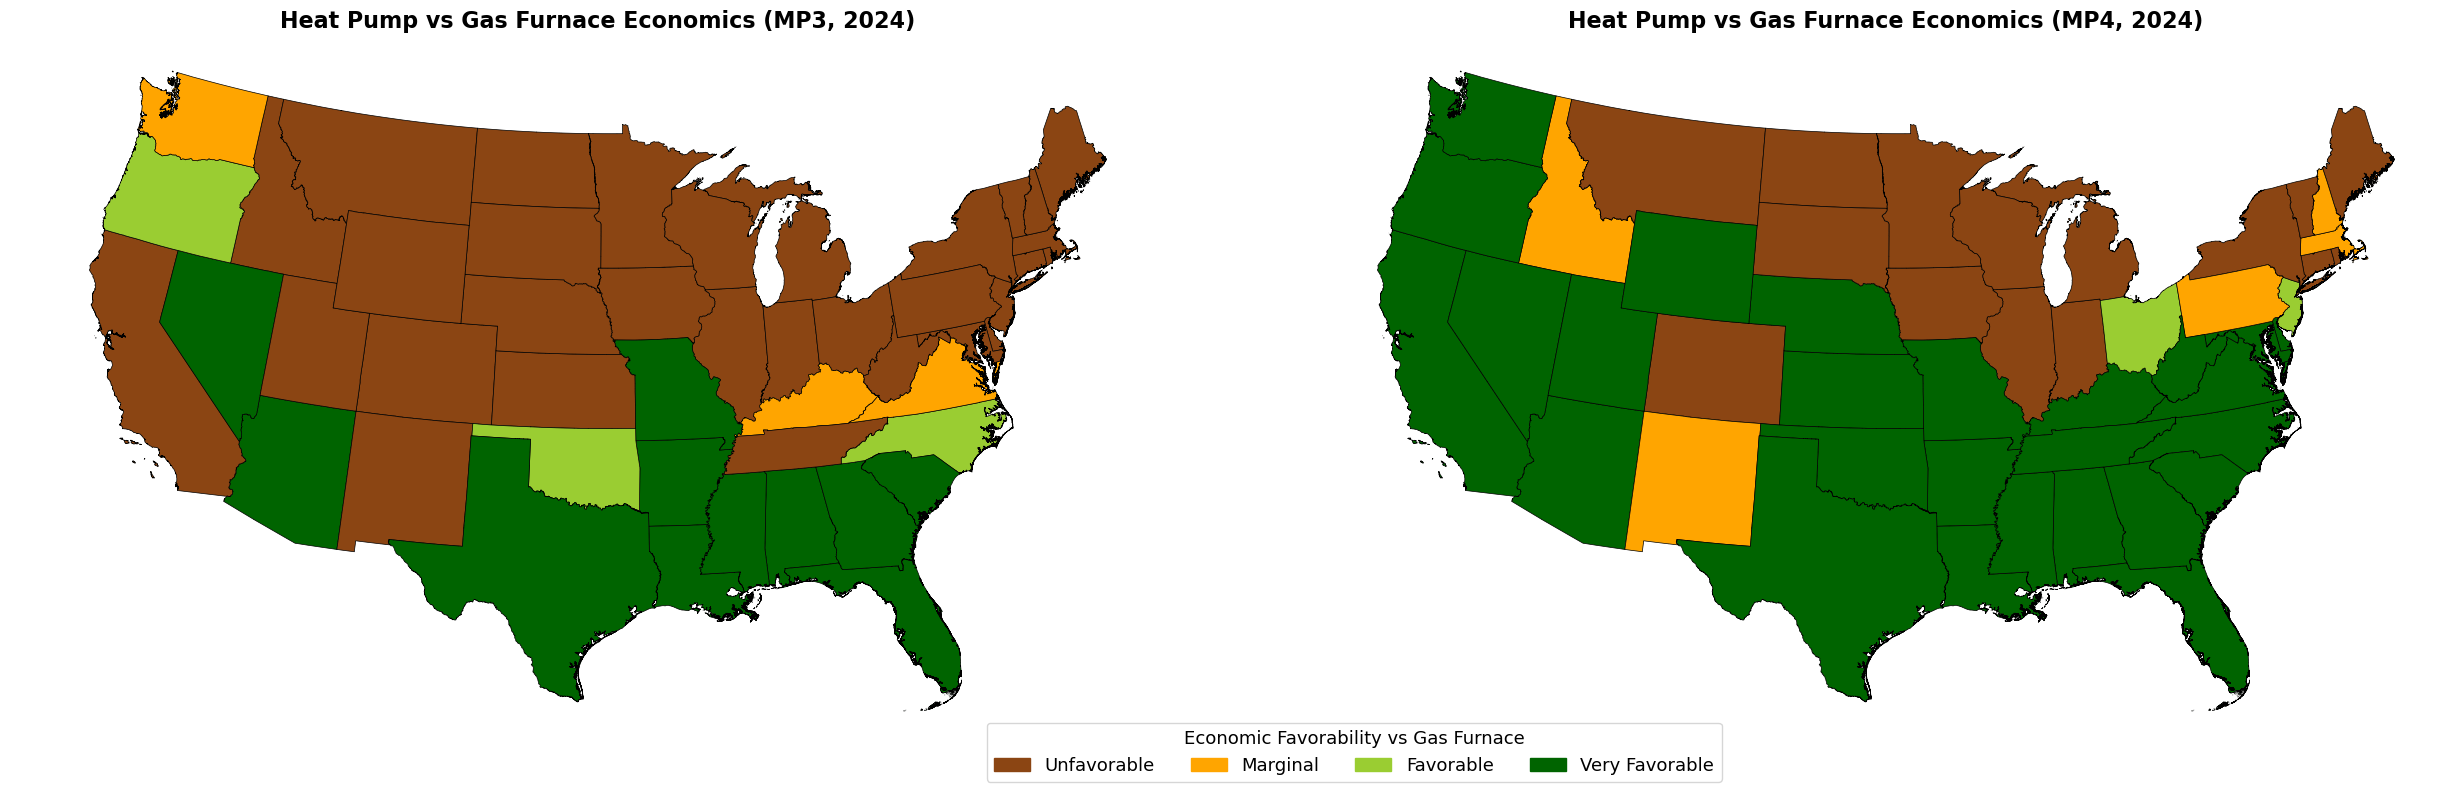

[OK] Categorical break-even map generated


In [11]:
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

if gdf_states_raw is not None:
    # ---- Build per-MP DataFrames with category codes ----
    cat_colors = ['#8B4513', '#FFA500', '#9ACD32', '#006400']
    cat_labels = ['Unfavorable', 'Marginal', 'Favorable', 'Very Favorable']
    cmap_cat = ListedColormap(cat_colors)
    norm_cat = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_cat.N)

    category_data = {}
    for mp in selected_mps:
        df = breakeven_results[mp].copy()
        df['thermal_cop'] = (
            cop_results[mp].set_index('state')['thermal_cop']
            .reindex(df['state'].values).values
        )
        conditions = [
            df['thermal_cop'] > df['breakeven_cop_95'],
            df['thermal_cop'] > df['breakeven_cop_90'],
            df['thermal_cop'] > df['breakeven_cop_80'],
        ]
        df['be_category'] = np.select(conditions, [3, 2, 1], default=0)
        category_data[mp] = df
        counts = df['be_category'].value_counts().sort_index()
        print(f"MP{mp} category counts:")
        for val, label in enumerate(cat_labels):
            print(f"  {label}: {counts.get(val, 0)} states")

    # ---- Combined categorical map, shared colormap ----
    n = len(selected_mps)
    fig = plt.figure(figsize=(14 * n, 8), facecolor='white')
    panel_w = 0.88 / n
    gap = 0.02

    for i, mp in enumerate(selected_mps):
        x0 = 0.02 + i * (panel_w + gap)
        w = panel_w - gap

        ax_main = fig.add_axes([x0, 0.06, w, 0.88])
        ax_ak   = fig.add_axes([x0, 0.06, w * 0.27, 0.26])

        plot_kw = dict(
            column='be_category', cmap=cmap_cat, norm=norm_cat,
            edgecolor='black', linewidth=0.5, legend=False,
        )
        _, gdf_conus, gdf_alaska = prepare_state_geodataframe(
            gdf_states_raw, category_data[mp], merge_col='state'
        )
        gdf_conus.plot(ax=ax_main, **plot_kw)
        ax_main.set_axis_off()
        ax_main.set_title(
            f'Heat Pump vs Gas Furnace Economics (MP{mp}, 2024)',
            fontsize=16, fontweight='bold', pad=8,
        )
        if not gdf_alaska.empty:
            gdf_alaska.plot(ax=ax_ak, **plot_kw)
        ax_ak.set_axis_off()

    # Shared categorical legend
    patches = [
        mpatches.Patch(color=cat_colors[i], label=cat_labels[i])
        for i in range(4)
    ]
    fig.legend(
        handles=patches, loc='lower center', ncol=4, fontsize=13,
        title='Economic Favorability vs Gas Furnace', title_fontsize=13,
        bbox_to_anchor=(0.5, 0.0),
    )

    if SAVE_FIGURES:
        for mp in selected_mps:
            out_path = os.path.join(
                PROJECT_ROOT, f'state_breakeven_categorical_mp{mp}_2024.png'
            )
            fig.savefig(out_path, dpi=600, bbox_inches='tight', facecolor='white')
            print(f"  Saved: {out_path}")

    plt.show()
    print("[OK] Categorical break-even map generated")
else:
    print("[WARN] Maps skipped — no geodataframe available")
